# Лабораторная работа 1. Обработка признаков.

## Задание

1. Выбрать набор данных (датасет), содержащий категориальные и числовые признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.) Просьба не использовать датасет, на котором данная задача решалась в лекции.
2. Для выбранного датасета (датасетов) на основе материалов лекций решить следующие задачи:
    1. устранение пропусков в данных;
    2. кодирование категориальных признаков;
    3. нормализация числовых признаков.

## Выполнение

In [17]:
%pip install pandas numpy seaborn matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

### 1. Выбрать набор данных (датасет), содержащий категориальные и числовые признаки и пропуски в данных

Выбран датасет [House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data?select=train.csv).

In [19]:
df = pd.read_csv('train.csv')

In [20]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Колонки с пропусками

In [21]:
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


### 2. Устранение пропусков в данных

- Для числовых признаков пропуски заполняются медианным значением
- Для категориальных признаков пропуски заполняются значением `NA`

In [22]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

C:\Users\dmitriy\AppData\Local\Temp\ipykernel_13676\441829498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [23]:
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [24]:
cat_imputer = SimpleImputer(strategy='constant', fill_value='NA')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

Пропуски после обработки

In [25]:
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

Series([], dtype: int64)


### 3. Кодирование категориальных признаков

Будет кодироваться признак `MSZoning` - тип жилой застройки

In [26]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [27]:
zoning_encoded = ohe.fit_transform(df[['MSZoning']])
zoning_df = pd.DataFrame(zoning_encoded, columns=ohe.get_feature_names_out(['MSZoning']))

In [28]:
df = pd.concat([df, zoning_df], axis=1).drop('MSZoning', axis=1)

In [29]:
print(df.filter(like='MSZoning').head())

   MSZoning_C (all)  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM
0               0.0          0.0          0.0          1.0          0.0
1               0.0          0.0          0.0          1.0          0.0
2               0.0          0.0          0.0          1.0          0.0
3               0.0          0.0          0.0          1.0          0.0
4               0.0          0.0          0.0          1.0          0.0


### 4. Нормализация числовых признаков

In [30]:
scaler = MinMaxScaler()

cols_to_scale = ['GrLivArea', 'LotArea', 'LotFrontage']

df_before = df[cols_to_scale].copy()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df[cols_to_scale].head())

   GrLivArea   LotArea  LotFrontage
0   0.259231  0.033420     0.150685
1   0.174830  0.038795     0.202055
2   0.273549  0.046507     0.160959
3   0.260550  0.038561     0.133562
4   0.351168  0.060576     0.215753


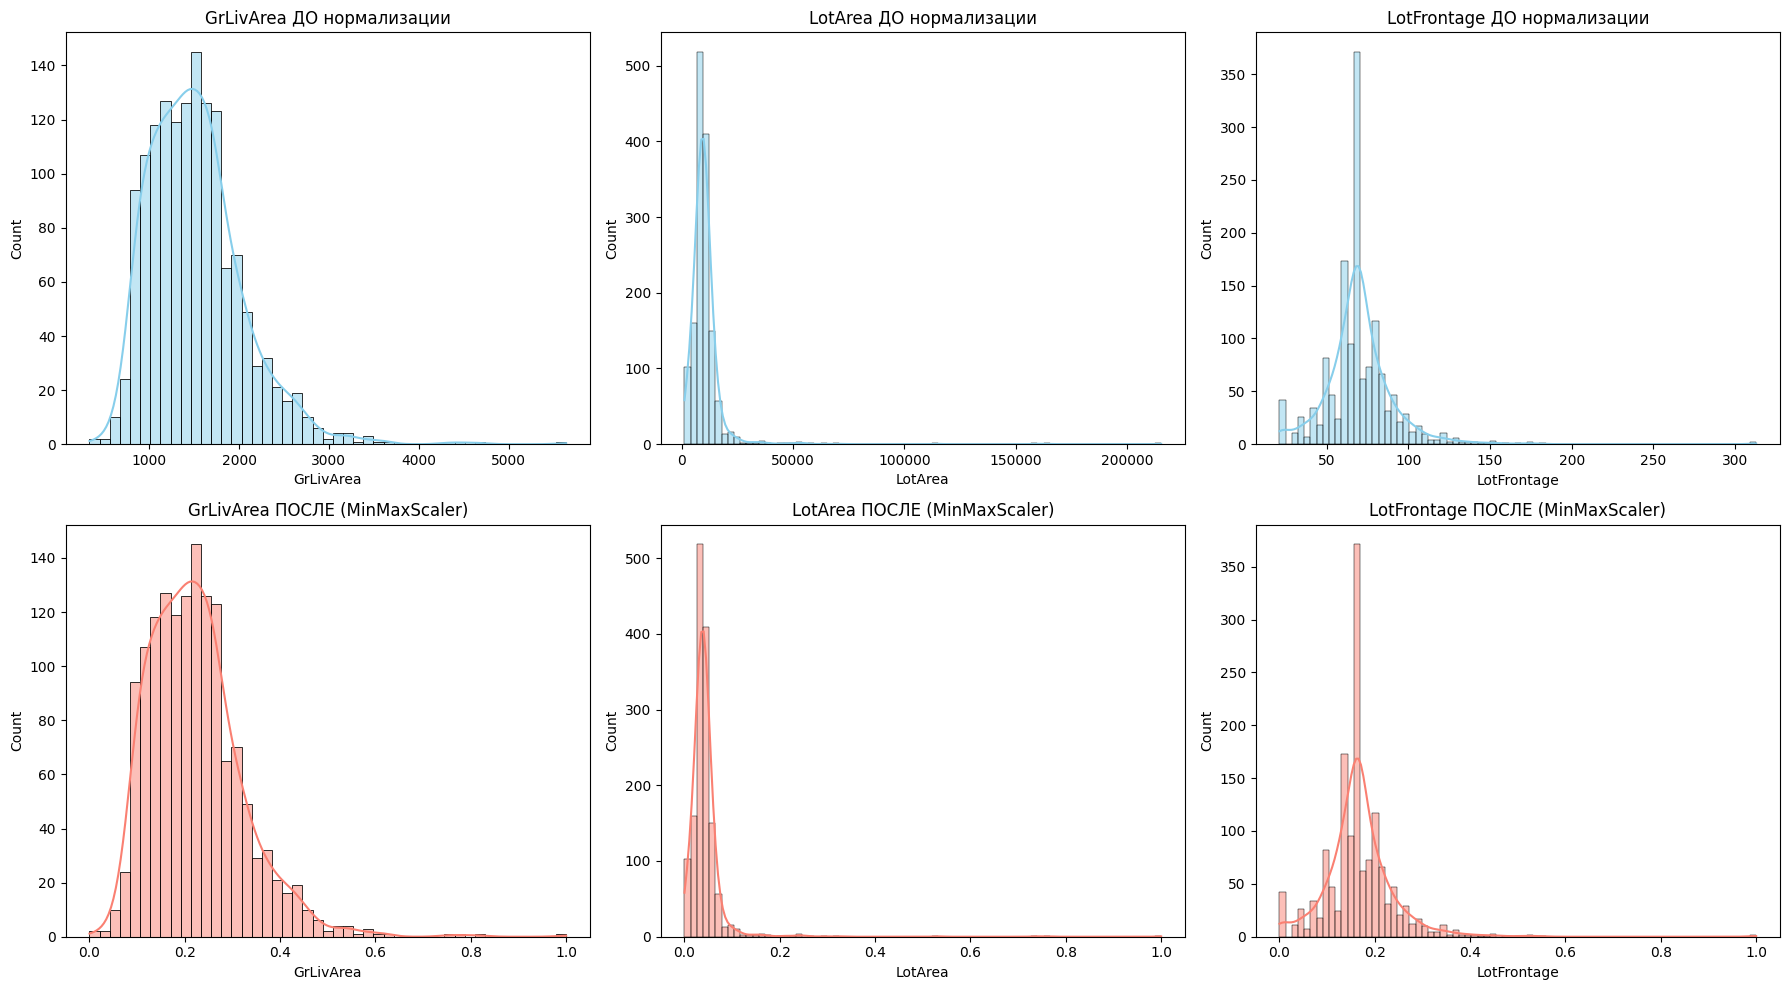

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

for i, col in enumerate(cols_to_scale):
    sns.histplot(df_before[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'{col} ДО нормализации')
    
    sns.histplot(df[col], kde=True, ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'{col} ПОСЛЕ (MinMaxScaler)')

plt.tight_layout()
plt.show()